In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL.Image import linear_gradient

In [3]:
uploaded = files.upload()

image_name = next(iter(uploaded))
image_path = '/content/' + image_name
image = cv2.imread(image_path)

if image is None:
  raise ValueError('Image Could Not Be Read. Please Check The Image File.')

print('Selected Image:', image_path)
print('Image Shape:', image.shape)

Saving Weeki-Wachee-Spring.jpg to Weeki-Wachee-Spring.jpg
Selected Image: /content/Weeki-Wachee-Spring.jpg
Image Shape: (900, 900, 3)


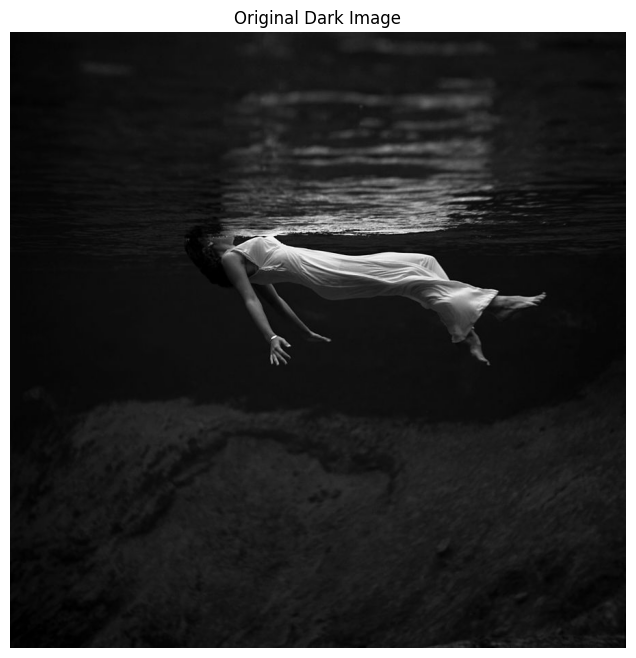

In [4]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=[8, 8])
plt.imshow(image_rgb)
plt.title('Original Dark Image')
plt.axis('off')

plt.show()

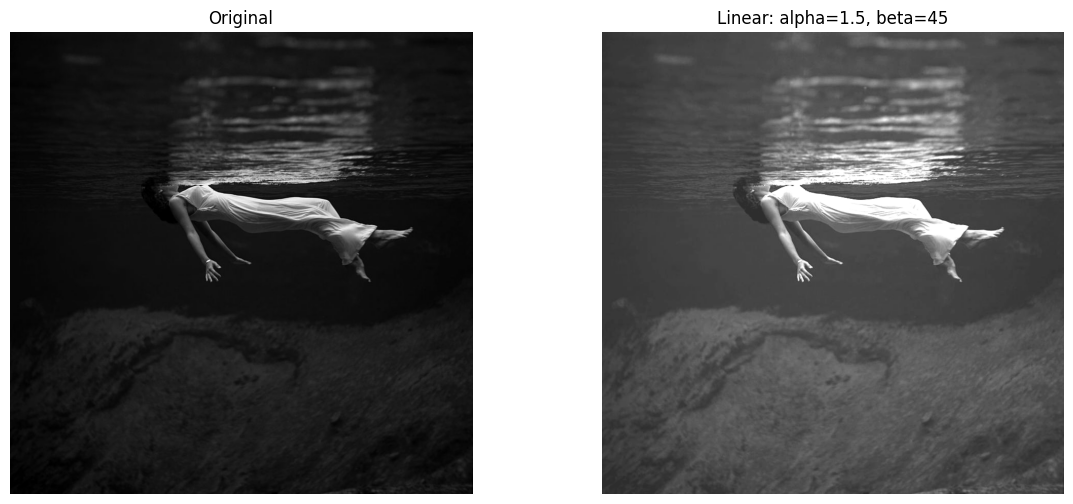

In [5]:
alpha = 1.5
beta = 45

linear_output = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
linear_output_rgb = cv2.cvtColor(linear_output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.subplot(121)
plt.imshow(image_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(122)
plt.imshow(linear_output_rgb)
plt.title(f'Linear: alpha={alpha}, beta={beta}')
plt.axis('off')

plt.show()

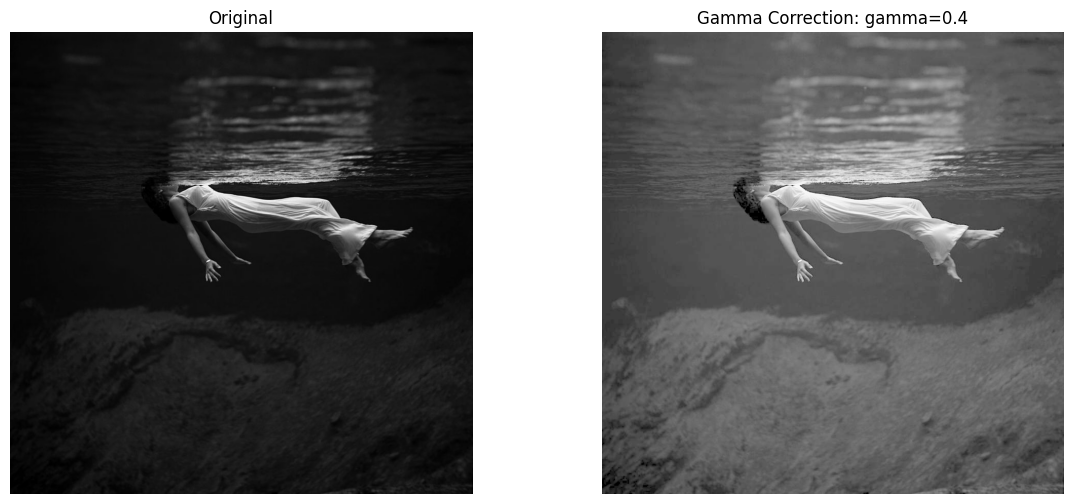

In [6]:
gamma = 0.4

lookup_table = np.empty((1, 256), dtype=np.uint8)

for i in range(256):
  lookup_table[0, i] = np.clip(
      ((i / 255.0) ** gamma) * 255.0,
      0,
      255
  )

gamma_output = cv2.LUT(image, lookup_table)
gamma_output_rgb = cv2.cvtColor(gamma_output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))
plt.subplot(121)
plt.imshow(image_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(122)
plt.imshow(gamma_output_rgb)
plt.title(f'Gamma Correction: gamma={gamma}')
plt.axis('off')

plt.show()

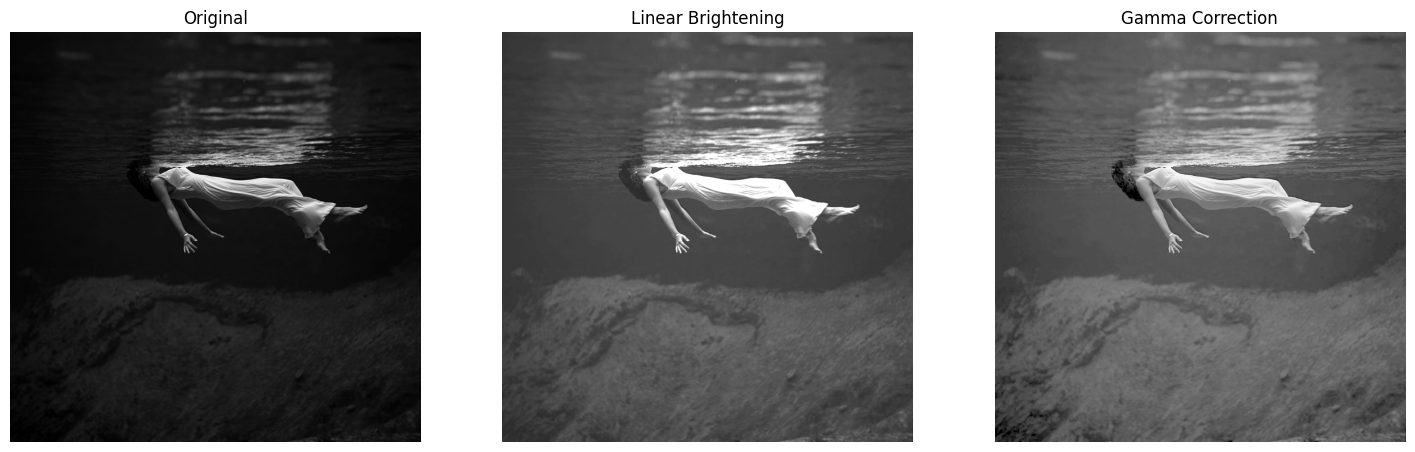

In [7]:
plt.figure(figsize=(18, 6))

plt.subplot(131)
plt.imshow(image_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(132)
plt.imshow(linear_output_rgb)
plt.title('Linear Brightening')
plt.axis('off')

plt.subplot(133)
plt.imshow(gamma_output_rgb)
plt.title('Gamma Correction')
plt.axis('off')

plt.show()

/tmp/ipykernel_1663/2859682756.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray_original.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_1663/2859682756.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray_linear.ravel(), 256, [0, 256], color='orange')
/tmp/ipykernel_1663/2859682756.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray_gamma.ravel(), 256, [0, 256], color='green')


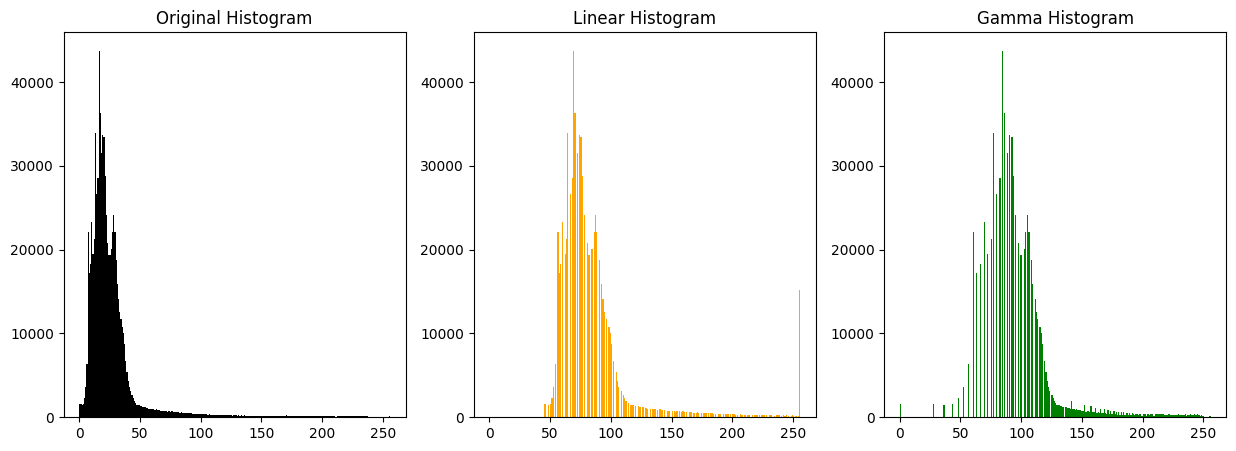

In [8]:
gray_original = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_linear = cv2.cvtColor(linear_output, cv2.COLOR_BGR2GRAY)
gray_gamma = cv2.cvtColor(gamma_output, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.hist(gray_original.ravel(), 256, [0, 256], color='black')
plt.title('Original Histogram')

plt.subplot(132)
plt.hist(gray_linear.ravel(), 256, [0, 256], color='orange')
plt.title('Linear Histogram')

plt.subplot(133)
plt.hist(gray_gamma.ravel(), 256, [0, 256], color='green')
plt.title('Gamma Histogram')

plt.show()